# 콜수요 초과레벨 지표 고도화 프로젝트

### 콜수요초과 LV

- 정의
  - 지역 내에 콜 수요가 얼마나 드라이버 공급을 초과하는지 수치화한 지표
  - 매 1분 실시간으로 지역별 계산, 지역별 콜 수 대비 드라이버 적절한지, 배차가 원할한지 인프라 상황 종합적 수치화 지표
    - 콜배차 소요시간, 콜수요초과LV는 경향 및 추세가 일치
    - 콜수요초과LV를 기초로 어떤 지역이 얼마나 개선점을 가지는 지 확인 및 실시간 대응 + 분석 활용 가능
    - LV 1~ 0
    - 콜수요초과LV 측정 단위 지역
    - 매 1분 계산

- 활용
  - 콜수요초과 수준에 따라 적절한 대응에 활용
    - 드라이버: 할증추가하여 콜비용 상승으로 더 많은 드라이버 활성화
    - 고객: 잘 안잡힐 것이라는 알린 노출
    - 운영업무 담당자: 실시간 수기 모니터링하여 운영 조치
 
- 공식
  - 콜수요초과LV = (배차대기 콜 건수 * W1 + 배치완료 콜 건수 * W2) / (배차 가능 드라이버 수 * W3 + 배차 완료 드라이버 수 * W4)

In [20]:
import matplotlib.font_manager as fm
fm.fontManager.ttflist

# 나눔글꼴 경로 설정
font_path = '/Users/jin/AppData/Local/Microsoft/Windows/Fonts/NanumSquareOTF_0.otf'

# 폰트 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 폰트 설정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus']=False

In [28]:
import pandas as pd

# df1 = call 과 관련된 정보(콜 등록 시간, 배차 완료 시간, 차이 시간, 지역)
# df2 = call LV데이터
df1 = pd.read_csv('~\side\O2O\data\T1_콜수요초과율_call.csv', encoding='cp949')
df2 = pd.read_csv('~\side\O2O\data\T1_콜수요초과율_LV.csv', encoding='cp949')
df1

,call_id,partition_date,registered_tm,consigned_tm,rec_regist_diff,region_id,region_nm
0,20250409_0264SISZ,2025.4.9,2025-04-09T13:18:48,2025-04-09T13:21:01.658,2,6363,원주
1,20250409_3367YZYS,2025.4.9,2025-04-09T09:57:11,2025-04-09T10:03:31.483,6,6363,원주
2,20250409_9742JYHC,2025.4.9,2025-04-09T16:35:00,2025-04-09T16:55:16.392,20,6363,원주
3,20250409_0141DXDK,2025.4.9,2025-04-09T17:56:20,2025-04-09T18:00:03.657,3,202,역삼
4,20250409_2989CLXZ,2025.4.9,2025-04-09T16:35:07,2025-04-09T16:39:23.371,4,202,역삼
...,...,...,...,...,...,...,...
29279,20250409_5562CFJJ,2025.4.9,2025-04-10T02:07:56,2025-04-10T02:08:37.518,0,202,역삼
29280,20250409_6168IXKF,2025.4.9,2025-04-09T19:27:52,2025-04-09T19:43:03.732,15,202,역삼
29281,20250409_6267WBPW,2025.4.9,2025-04-09T13:47:49,2025-04-09T13:50:05.498,2,202,역삼
29282,20250409_8315MJDZ,2025.4.9,2025-04-09T19:40:37,2025-04-09T19:42:48.639,2,202,역삼


In [22]:
df2

,region_nm,region_id,partition_date,hour_part,min_part,real_timeline,call_ov_LV
0,원주,6363,2025.4.9,17,17:23:00,2025-04-09T17:23:00+09:00,4
1,원주,6363,2025.4.9,22,22:03:00,2025-04-09T22:03:00+09:00,4
2,원주,6363,2025.4.9,14,14:58:00,2025-04-09T14:58:00+09:00,1
3,원주,6363,2025.4.9,18,18:15:00,2025-04-09T18:15:00+09:00,6
4,원주,6363,2025.4.9,13,13:38:00,2025-04-09T13:38:00+09:00,1
...,...,...,...,...,...,...,...
5755,역삼,202,2025-04-08,7,07:00:00,2025-04-08T07:00:00+09:00,2
5756,역삼,202,2025-04-08,15,15:11:00,2025-04-08T15:11:00+09:00,1
5757,역삼,202,2025-04-08,16,16:49:00,2025-04-08T16:49:00+09:00,1
5758,역삼,202,2025-04-08,23,23:35:00,2025-04-08T23:35:00+09:00,2


In [29]:
# SQL

import duckdb

duckdb.register('df1', df1)
duckdb.register('df2', df2)


df_result = duckdb.query("""

      with call_base as (
      select
          partition_date
          , case when extract(hour from cast(registered_tm as timestamp)) < 5
                      then lpad(cast(extract(hour from cast(registered_tm as timestamp)) + 24 as varchar) ,2,'0') || ':' || lpad(cast(cast(floor(extract(minute from cast(registered_tm as timestamp)) / 30) *30 as int) as varchar), 2,'0') ||  ':00'
                  else lpad(cast(extract(hour from cast(registered_tm as timestamp)) as varchar) ,2,'0') || ':' || lpad(cast(cast(floor(extract(minute from cast(registered_tm as timestamp)) / 30) *30 as int) as varchar), 2,'0') ||  ':00'
                  end as min_part
          , region_nm
          , region_id
          , avg(rec_regist_diff) as rec_regist_diff

      from df1
      group by 1,2,3,4
      )

      , ov_LV_base as (

      select
          partition_date
          , region_nm
          , region_id
          , min_part2
          , avg(call_ov_LV) as call_ov_LV
      from (
            select *
              , case when extract(hour from cast(real_timeline_kst as timestamp)) < 5
                                  then lpad(cast(extract(hour from cast(real_timeline_kst as timestamp)) + 24 as varchar) ,2,'0') || ':' || lpad(cast(cast(floor(extract(minute from cast(real_timeline_kst as timestamp)) / 30) *30 as int) as varchar), 2,'0') ||  ':00'
                              else lpad(cast(extract(hour from cast(real_timeline_kst as timestamp)) as varchar) ,2,'0') || ':' || lpad(cast(cast(floor(extract(minute from cast(real_timeline_kst as timestamp)) / 30) *30 as int) as varchar), 2,'0') ||  ':00'
                              end as min_part2
            from (
                    select *
                      , CAST(real_timeline AS TIMESTAMP) + INTERVAL '9 hours' AS real_timeline_kst

                    from df2
                  )
            )
      group by 1,2,3,4
      )


      select c.*
          , o.call_ov_LV
      from call_base as c
      left join ov_LV_base as o
        on c.region_id = o.region_id
        and c.partition_date = o.partition_date
        and c.min_part = o.min_part2
      where 1=1



""").to_df()

df_result.head()

,partition_date,min_part,region_nm,region_id,rec_regist_diff,call_ov_LV
0,2025.4.9,18:00:00,역삼,202,6.226615,1.233333
1,2025.4.9,15:30:00,원주,6363,7.924528,3.833333
2,2025.4.9,25:00:00,역삼,202,5.299180,1.466667
3,2025.4.9,11:00:00,원주,6363,8.094737,3.333333
4,2025.4.9,16:30:00,역삼,202,4.773305,1.233333


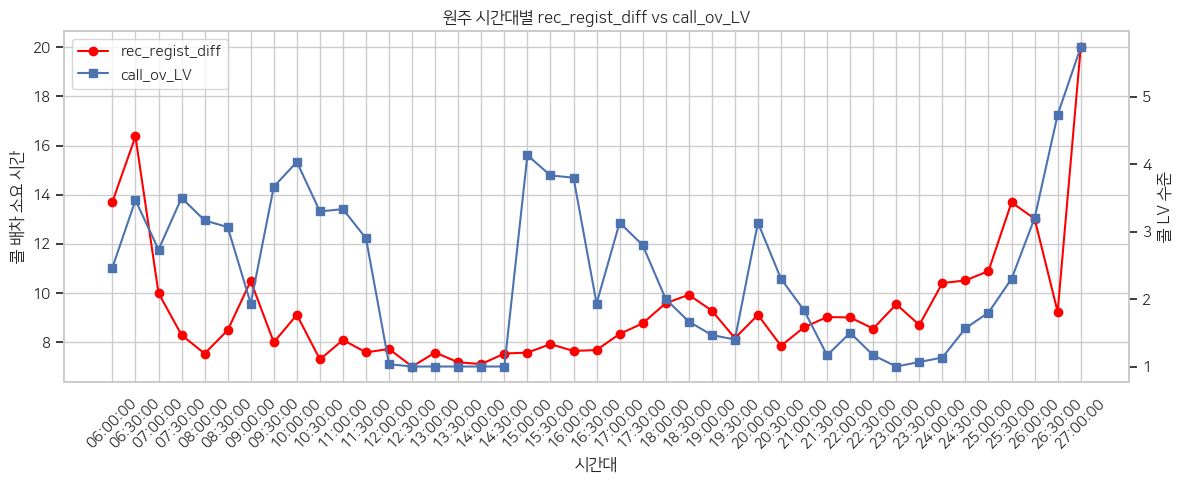

In [32]:
%matplotlib inline
df_plot = df_result.query("region_nm == '원주'").sort_values("min_part")

fig, ax1 = plt.subplots(figsize=(12,5))
plt.xticks(rotation=45)

line1 = ax1.plot(df_plot["min_part"], df_plot["rec_regist_diff"],
                 marker="o", label="rec_regist_diff", color = 'red')
ax1.set_xlabel("시간대")
ax1.set_ylabel("콜 배차 소요 시간")

ax2 = ax1.twinx()
line2 = ax2.plot(df_plot["min_part"], df_plot["call_ov_LV"],
                 marker="s", label="call_ov_LV")
ax2.set_ylabel("콜 LV 수준")

# 두 축의 핸들/라벨을 합쳐서 한 번에 legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("원주 시간대별 rec_regist_diff vs call_ov_LV")
plt.grid(False)
plt.tight_layout()
plt.show()

In [37]:
df_result[df_result["min_part"]=="27:00:00"].shape[0]

2

- 고려되지 않은 부분

추천, 거리, 추세, 드라이버 품질, 콜 난이도, 시간대 특성

- 보정 지표 필요함

추천 횟수, 평균 거리, 최근 N분 평균(이동 평균), 콜 수락률 들

그래서 기본 LV지표에서 마지막에 `+추천(거리)관련 보정 지표 * W5 시행`

Y값을 콜 배차 소요시간 평균으로 사용해서 분석

## Uber의 H3index 분석

In [38]:
import pandas as pd
import folium
from folium import FeatureGroup
from folium.features import GeoJson, GeoJsonTooltip
from branca.colormap import linear

import h3
from shapely.geometry import Polygon
import geopandas as gpd


# ------------------------------------------------------------
# 1) 데이터 로드
# ------------------------------------------------------------
call_geo = pd.read_csv("~\side\O2O\data\T2_call_latlng.csv")
driver_geo = pd.read_csv("~\side\O2O\data\T2_driver_latlng.csv")


In [39]:
call_geo

,call_id,region_nm,register_kst,register_hour,call_lat,call_lng,call_h3_idx_lv5,call_h3_idx_lv6,call_h3_idx_lv7,call_h3_idx_lv8,call_h3_idx_lv9,call_h3_idx_lv10
0,20250409_6947ZPJQ,원주,2025-04-10T02:51:34,26:30:00,37.320111,127.944107,8530ee9bfffffff,8630ee9afffffff,8730ee9aeffffff,8830ee9aedfffff,8930ee9aedbffff,8a30ee9aed97fff
1,20250409_2149UAQI,원주,2025-04-10T02:50:52,26:30:00,37.362606,127.936634,8530ee93fffffff,8630ee917ffffff,8730ee912ffffff,8830ee9129fffff,8930ee91287ffff,8a30ee912877fff
2,20250409_6961WKFN,원주,2025-04-10T02:50:08,26:30:00,37.323750,127.957384,8530ee9bfffffff,8630ee9afffffff,8730ee9aeffffff,8830ee9ae1fffff,8930ee9ae07ffff,8a30ee9ae047fff
3,20250409_1623FFDE,원주,2025-04-10T02:53:19,26:30:00,37.348052,127.932302,8530ee93fffffff,8630ee917ffffff,8730ee912ffffff,8830ee9125fffff,8930ee9125bffff,8a30ee9125a7fff
4,20250409_9879SJRY,원주,2025-04-10T02:56:39,26:30:00,37.347469,127.931802,8530ee93fffffff,8630ee917ffffff,8730ee912ffffff,8830ee9125fffff,8930ee9125bffff,8a30ee9125b7fff
5,20250409_8944NMZJ,원주,2025-04-10T03:00:06,27:00:00,37.320111,127.944107,8530ee9bfffffff,8630ee9afffffff,8730ee9aeffffff,8830ee9aedfffff,8930ee9aedbffff,8a30ee9aed97fff
6,20250409_0774MHAQ,원주,2025-04-10T02:57:16,26:30:00,37.350108,127.943662,8530ee93fffffff,8630ee917ffffff,8730ee912ffffff,8830ee9127fffff,8930ee91277ffff,8a30ee912757fff
7,20250409_6314JEWK,원주,2025-04-10T02:50:08,26:30:00,37.369963,127.936704,8530ee93fffffff,8630ee917ffffff,8730ee910ffffff,8830ee9105fffff,8930ee91053ffff,8a30ee91050ffff
8,20250409_8456UUMW,원주,2025-04-10T02:50:30,26:30:00,37.348021,127.932760,8530ee93fffffff,8630ee917ffffff,8730ee912ffffff,8830ee9125fffff,8930ee9125bffff,8a30ee9125a7fff


In [40]:
driver_geo

,driver_id,lat,lng,collectdate,part_date,collectdate_kst,register_hour,register_min,h3_lv6_str,h3_lv7_str,h3_lv8_str,h3_lv9_str,h3_lv10_str
0,FB8DDDC75530F9FA36142999CAC405F757F9BEA3C6A070...,37.346592,127.930452,2025-04-09T17:56:00,2025.4.9,2025-04-10T02:56:00,26:30:00,2025-04-10T02:56:00,8630ee9a7ffffff,8730ee9a5ffffff,8830ee9a53fffff,8930ee9a52fffff,8a30ee9a52c7fff
1,F075216C955C4CFFC1A7020AF59691F350DDC47D233A92...,37.331428,127.941112,2025-04-09T17:56:00,2025.4.9,2025-04-10T02:56:00,26:30:00,2025-04-10T02:56:00,8630ee9a7ffffff,8730ee9a1ffffff,8830ee9a17fffff,8930ee9a177ffff,8a30ee9a1777fff
2,12387F6967725332E8CF747CD31023015F260DF031F5B5...,37.302223,127.921223,2025-04-09T17:56:00,2025.4.9,2025-04-10T02:56:00,26:30:00,2025-04-10T02:56:00,8630ee9a7ffffff,8730ee9a2ffffff,8830ee9a27fffff,8930ee9a263ffff,8a30ee9a262ffff
3,5A1B0A9B86F6B951A97AD22117FA0986A23F29CDBC9992...,37.348501,127.932536,2025-04-09T17:57:00,2025.4.9,2025-04-10T02:57:00,26:30:00,2025-04-10T02:57:00,8630ee9a7ffffff,8730ee912ffffff,8830ee9125fffff,8930ee9125bffff,8a30ee9125a7fff
4,F075216C955C4CFFC1A7020AF59691F350DDC47D233A92...,37.336178,127.934733,2025-04-09T17:57:00,2025.4.9,2025-04-10T02:57:00,26:30:00,2025-04-10T02:57:00,8630ee9a7ffffff,8730ee9a1ffffff,8830ee9a11fffff,8930ee9a113ffff,8a30ee9a1117fff
5,12387F6967725332E8CF747CD31023015F260DF031F5B5...,37.306293,127.921197,2025-04-09T17:55:00,2025.4.9,2025-04-10T02:55:00,26:30:00,2025-04-10T02:55:00,8630ee9a7ffffff,8730ee9a2ffffff,8830ee9a23fffff,8930ee9a23bffff,8a30ee9a2397fff
6,15202DE35E5D8D6D8A42E59E728A6651603913F5967663...,37.325523,127.958279,2025-04-09T17:56:00,2025.4.9,2025-04-10T02:56:00,26:30:00,2025-04-10T02:56:00,8630ee9afffffff,8730ee9aeffffff,8830ee9aebfffff,8930ee9aeabffff,8a30ee9aea9ffff
7,3C18C157C97EF98E43B63782650E8A29BDAA17E7C8CA35...,37.354991,127.898918,2025-04-09T18:00:00,2025.4.9,2025-04-10T03:00:00,27:00:00,2025-04-10T03:00:00,8630e164fffffff,8730e164bffffff,8830e164b5fffff,8930e164b57ffff,8a30e164b557fff
8,EA0C62079F63C774DF251F2C26CECA43432E5FBA3D33E7...,37.337041,127.922974,2025-04-09T17:57:00,2025.4.9,2025-04-10T02:57:00,26:30:00,2025-04-10T02:57:00,8630ee9a7ffffff,8730ee9a5ffffff,8830ee9a0bfffff,8930ee9a0b7ffff,8a30ee9a0b4ffff
9,F0C3D65C91EC5496A962F88556895865E0BF432914CE32...,37.317714,127.938290,2025-04-09T17:55:00,2025.4.9,2025-04-10T02:55:00,26:30:00,2025-04-10T02:55:00,8630ee9a7ffffff,8730ee9a3ffffff,8830ee9a31fffff,8930ee9a3abffff,8a30ee9a3a97fff


In [41]:
# ------------------------------------------------------------
# 2) H3 셀별 건수 집계
#    - call: call_h3_idx_lv8 기준으로 cnt_call 계산
#    - driver: h3_lv8_str 기준으로 cnt_driver 계산
# ------------------------------------------------------------
call_aggr = (
    call_geo.groupby("call_h3_idx_lv8")
            .size()
            .reset_index(name="cnt_call")
            .rename(columns={"call_h3_idx_lv8": "h3_address"})
)

driver_aggr = (
    driver_geo.groupby("h3_lv8_str")
              .size()
              .reset_index(name="cnt_driver")
              .rename(columns={"h3_lv8_str": "h3_address"})
)

In [42]:
# ------------------------------------------------------------
# 3) H3 셀 주소 -> 폴리곤(경계) 만들기
#    - h3.h3_to_geo_boundary(h, geo_json=True)는 (lat,lng) 목록 반환
#    - shapely Polygon은 (lng,lat) 순서를 선호하므로 좌표 순서 뒤집어 생성
# ------------------------------------------------------------
def h3_to_polygon(h):
    # v4 함수
    boundary = h3.cell_to_boundary(h)  # [(lat, lng), ...]
    
    # shapely는 (lng, lat) 순서
    return Polygon([(lng, lat) for lat, lng in boundary])

# call / driver 각각 GeoDataFrame 생성
call_aggr["geometry"] = call_aggr["h3_address"].apply(h3_to_polygon)
driver_aggr["geometry"] = driver_aggr["h3_address"].apply(h3_to_polygon)

gdf_call = gpd.GeoDataFrame(call_aggr, geometry="geometry", crs="EPSG:4326")
gdf_driver = gpd.GeoDataFrame(driver_aggr, geometry="geometry", crs="EPSG:4326")

In [43]:
# ------------------------------------------------------------
# 4) 지도 중심 잡기
#    - 두 레이어의 폴리곤 중심점을 합쳐 평균으로 지도 center 추정
# ------------------------------------------------------------
all_centroids = pd.concat([
    gdf_call.geometry.centroid,
    gdf_driver.geometry.centroid
], ignore_index=True)

center_lat = all_centroids.y.mean()
center_lng = all_centroids.x.mean()

In [44]:
# ------------------------------------------------------------
# 5) Folium 지도 생성 (배경: CartoDB DarkMatter)
# ------------------------------------------------------------
m = folium.Map(location=[center_lat, center_lng], zoom_start=11, tiles=None)
folium.TileLayer("CartoDB dark_matter", name="Basemap").add_to(m)

In [45]:
# ------------------------------------------------------------
# 6) 색상(레전드) 만들기
#    - R의 colorBin(bins=5) 느낌을 Python에서는
#      colormap(scale) + 값을 bins로 나눠 색을 뽑는 방식으로 구현
# ------------------------------------------------------------
# Call(파랑 계열)
call_min, call_max = float(gdf_call["cnt_call"].min()), float(gdf_call["cnt_call"].max())
call_cmap = linear.Blues_09.scale(call_min, call_max)
call_cmap.caption = "Call_count"

# Driver(빨강 계열)
drv_min, drv_max = float(gdf_driver["cnt_driver"].min()), float(gdf_driver["cnt_driver"].max())
drv_cmap = linear.Reds_09.scale(drv_min, drv_max)
drv_cmap.caption = "Driver_count"

In [46]:
# ------------------------------------------------------------
# 7) GeoJSON 스타일 함수(폴리곤 색칠)
# ------------------------------------------------------------
def style_call(feature):
    v = feature["properties"].get("cnt_call", 0) or 0
    return {
        "fillColor": call_cmap(v),
        "color": "white",
        "weight": 1,
        "fillOpacity": 0.7
    }

def style_driver(feature):
    v = feature["properties"].get("cnt_driver", 0) or 0
    return {
        "fillColor": drv_cmap(v),
        "color": "white",
        "weight": 1,
        "fillOpacity": 0.7
    }

In [47]:
# ------------------------------------------------------------
# 8) 레이어 추가 (Call_layer, Driver_layer)
#    - R의 addPolygons + popup에 해당
# ------------------------------------------------------------
call_layer = FeatureGroup(name="Call_layer", show=True)
driver_layer = FeatureGroup(name="Driver_layer", show=True)

GeoJson(
    gdf_call.to_json(),
    style_function=style_call,
    tooltip=GeoJsonTooltip(fields=["cnt_call"], aliases=["cnt_call"])
).add_to(call_layer)

GeoJson(
    gdf_driver.to_json(),
    style_function=style_driver,
    tooltip=GeoJsonTooltip(fields=["cnt_driver"], aliases=["cnt_driver"])
).add_to(driver_layer)

call_layer.add_to(m)
driver_layer.add_to(m)

In [48]:
# ------------------------------------------------------------
# 9) 레전드 + 레이어 컨트롤
#    - R의 addLegend + addLayersControl 대응
# ------------------------------------------------------------
call_cmap.add_to(m)
drv_cmap.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

In [49]:
m

## 보정값 가설 설정

문제 파악해봤을 때 콜배차소요시간과 콜수요초과LV가 맞지 않는 상황이 발생
- 앞서 말했던 신규 지표 수식 추가 (W5 * 1/추천성공률)

In [60]:
df3 = pd.read_csv('~\side\O2O\data\T3_콜수요초과_추천로그_원주.csv', encoding='utf-8')
df3.head()

,cal_result,individual_call_id,call_ids,calculation_id,driver_id,selecteddriver_id,action_time,region_id,region_nm,call_ov_LV,business_day
0,ACCEPTED,0282DBVA,0282DBVA,421300120230901:20250409:f3f464fa52f14f96b31b6...,801E68B51D20A8E10AB5C53F584A65AA111A65761DC4E1...,801E68B51D20A8E10AB5C53F584A65AA111A65761DC4E1...,2025-04-10 00:52:00,6363,원주,3,2025.4.9
1,ACCEPTED,6588SSDW,6588SSDW,421300120230901:20250409:714d078eabd344539550b...,DED5D56D52C9434E611A4305B3F0D7BBBF5B32CF678C38...,DED5D56D52C9434E611A4305B3F0D7BBBF5B32CF678C38...,2025-04-10 00:58:00,6363,원주,4,2025.4.9
2,ACCEPTED,0522KEDE,0522KEDE,421300120230901:20250409:61d31b6d7006494397d32...,38CAFDC423A6724A43233406758A628E7FE0AD643FCD72...,38CAFDC423A6724A43233406758A628E7FE0AD643FCD72...,2025-04-10 01:32:00,6363,원주,3,2025.4.9
3,REJECTED,8847SAZP,8847SAZP#8453VDCQ,421300120230901:20250409:796f238bf8694da7a3dc4...,2A46D2C81DE9718A7140C00E88179319362F50BCAB93F0...,2A46D2C81DE9718A7140C00E88179319362F50BCAB93F0...,2025-04-10 01:39:00,6363,원주,3,2025.4.9
4,REJECTED,8453VDCQ,8847SAZP#8453VDCQ,421300120230901:20250409:796f238bf8694da7a3dc4...,2A46D2C81DE9718A7140C00E88179319362F50BCAB93F0...,2A46D2C81DE9718A7140C00E88179319362F50BCAB93F0...,2025-04-10 01:39:00,6363,원주,3,2025.4.9


In [63]:
duckdb.register('df3', df3)


df_result2 = duckdb.query("""
WITH
-- 1) df3에서 성공/실패 플래그 생성
base1 AS (
  SELECT
      *,
      CASE WHEN cal_result = 'selected' THEN 1 ELSE 0 END AS is_recom_successed,
      CASE WHEN cal_result = 'failed'   THEN 1 ELSE 0 END AS is_recom_failed
  FROM df3
),

-- 2) 이벤트 중복 압축(같은 키 중복 제거 목적)
base2 AS (
  SELECT
      cal_result,
      individual_call_id,
      calculation_id,
      business_day,
      CAST(action_time AS TIMESTAMP) AS action_time,
      call_ov_LV,
      region_id,
      region_nm,
      MAX(is_recom_successed) AS is_recom_successed,
      MAX(is_recom_failed)    AS is_recom_failed
  FROM base1
  GROUP BY 1,2,3,4,5,6,7,8
),

-- 3) lag를 한 번만 계산해서 time diff 및 non_rec_cnt 산출
base3 AS (
  SELECT
      *,
      LAG(action_time) OVER (PARTITION BY individual_call_id ORDER BY action_time) AS prev_action_time,
      DATEDIFF('second',
               LAG(action_time) OVER (PARTITION BY individual_call_id ORDER BY action_time),
               action_time
      ) AS diff_sec
  FROM base2
),

-- 4) non_rec_cnt 계산(원 로직 유지)
base3b AS (
  SELECT
      cal_result,
      individual_call_id,
      calculation_id,
      business_day,
      action_time,
      region_id,
      region_nm,
      is_recom_successed,
      is_recom_failed,
      CASE
        WHEN cal_result IN ('REJECTED','ACCEPTED','CANCELED') THEN 0
        WHEN diff_sec IS NULL THEN 0
        WHEN (diff_sec / 15.0) - 1 < 0 THEN 0
        ELSE FLOOR(diff_sec / 15.0)
      END AS non_rec_cnt
  FROM base3
),

-- 5) df2에서 (날짜/지역/30분버킷)별 call_ov_LV 평균
ov_LV_base AS (
  SELECT
      partition_date,
      region_nm,
      region_id,
      printf(
        '%02d:%02d:00',
        CAST(EXTRACT(HOUR FROM ts_kst) AS INT) + CASE WHEN EXTRACT(HOUR FROM ts_kst) < 5 THEN 24 ELSE 0 END,
        CAST(FLOOR(EXTRACT(MINUTE FROM ts_kst) / 30) * 30 AS INT)
      ) AS min_part2,
      AVG(call_ov_LV) AS call_ov_LV
  FROM (
    SELECT
        *,
        CAST(real_timeline AS TIMESTAMP) + INTERVAL '9 hours' AS ts_kst
    FROM df2
  )
  GROUP BY 1,2,3,4
),

-- 6) df3 기반 추천 로그를 (지역/일자/30분버킷)로 집계
base4 AS (
  SELECT
      region_nm,
      region_id,
      business_day,
      printf(
        '%02d:%02d:00',
        CAST(EXTRACT(HOUR FROM action_time) AS INT) + CASE WHEN EXTRACT(HOUR FROM action_time) < 5 THEN 24 ELSE 0 END,
        CAST(FLOOR(EXTRACT(MINUTE FROM action_time) / 30) * 30 AS INT)
      ) AS min_part2,

      -- 추천 시도/성공/실패/비추천 추정
      SUM(COALESCE(is_recom_successed,0)) + SUM(COALESCE(is_recom_failed,0)) AS recom_cnt,
      SUM(COALESCE(is_recom_successed,0)) AS recom_successed_cnt,
      SUM(COALESCE(is_recom_failed,0))    AS recom_failed_cnt,
      SUM(COALESCE(non_rec_cnt,0))        AS non_rec_cnt,

      -- 수락 건수
      COUNT(*) FILTER (WHERE cal_result = 'ACCEPTED') AS cnt_accept
  FROM base3b
  GROUP BY 1,2,3,4
)

-- 7) 성공률 계산 + ov/LV 조인
SELECT
    f.*,
    CASE
      WHEN (recom_successed_cnt + recom_failed_cnt + non_rec_cnt) = 0 THEN 0
      ELSE recom_successed_cnt * 100.0
           / (recom_successed_cnt + recom_failed_cnt + non_rec_cnt)
    END AS recom_successed_rate,
    o.call_ov_LV
FROM base4 f
LEFT JOIN ov_LV_base o
  ON f.region_id = o.region_id
 AND f.business_day = o.partition_date
 AND f.min_part2 = o.min_part2
""").to_df()

In [65]:
df_result2.head()

,region_nm,region_id,business_day,min_part2,recom_cnt,recom_successed_cnt,recom_failed_cnt,non_rec_cnt,cnt_accept,recom_successed_rate,call_ov_LV
0,원주,6363,2025.4.9,13:00:00,283.0,272.0,11.0,201.0,227,56.198347,1.000000
1,원주,6363,2025.4.9,13:30:00,276.0,265.0,11.0,279.0,195,47.747748,1.000000
2,원주,6363,2025.4.9,10:00:00,123.0,122.0,1.0,160.0,102,43.109541,4.033333
3,원주,6363,2025.4.9,23:00:00,270.0,258.0,12.0,305.0,180,44.869565,1.000000
4,원주,6363,2025.4.9,14:00:00,189.0,185.0,4.0,127.0,149,58.544304,1.000000


In [66]:
df_result.to_excel("df_result.xlsx", index=False)
df_result2.to_excel("df_result2.xlsx", index=False)

-> 다음 엑셀에서